# Feature Selection and Model Explainability

## Objective

The objective of this notebook is to identify the most informative features for predicting reactor yield.

Rather than assuming all engineered variables are useful, multiple feature selection techniques will be evaluated.

The selected feature subsets will be validated using repeated cross-validation.

Only feature subsets that improve validation RMSE will be retained.

This notebook also improves model interpretability by explaining which reactor variables most influence prediction performance.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import joblib

from sklearn.model_selection import (
    cross_val_score,
    RepeatedKFold
)

from sklearn.inspection import permutation_importance

from sklearn.feature_selection import RFE

from sklearn.ensemble import ExtraTreesRegressor

In [2]:
train = pd.read_csv(
    "../data/processed/train_engineered.csv"
)

X = train.drop(
    columns="overall_yield"
)

y = train["overall_yield"]

In [3]:
best_model = joblib.load(
    "../models/best_extra_trees.pkl"
)

In [4]:
cv = RepeatedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

In [5]:
best_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",700
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls 3 sources of randomness:- the bootstrapping of the samples used when building trees (if ``bootstrap=True``)- the sampling of the features to consider when looking for the best split at each node (if ``max_features < n_features``)- the draw of the splits for each of the `max_features`See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split indu

In [6]:
importance = permutation_importance(

    estimator=best_model,

    X=X,

    y=y,

    n_repeats=30,

    random_state=42

)

In [7]:
importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": importance.importances_mean

})

importance_df = importance_df.sort_values(

    "Importance",

    ascending=False

)

importance_df

,Feature,Importance
2,inlet_temperature_K,0.673476
4,jacket_temperature_K,0.631402
7,residence_time_proxy,0.065036
3,length_m,0.044755
5,temp_difference,0.040135
8,flow_length,0.038807
0,flow_rate_L_min,0.038672
6,temp_ratio,0.034379
10,flow_temp,0.028035
11,temp_severity,0.008278


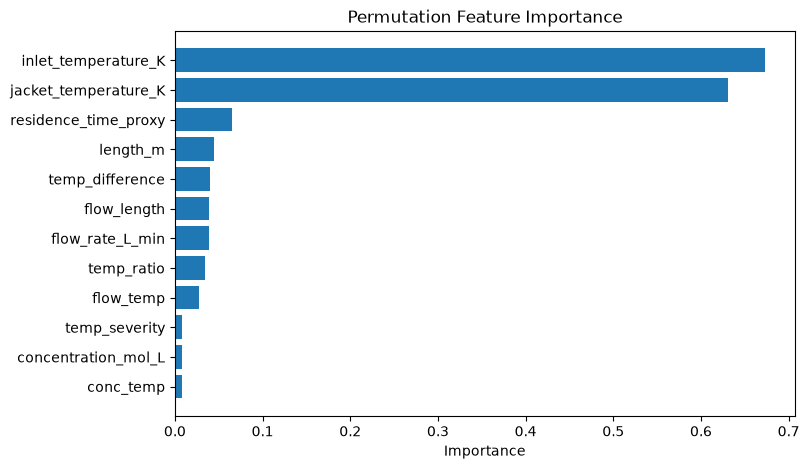

In [8]:
plt.figure(figsize=(8,5))

plt.barh(

    importance_df["Feature"],

    importance_df["Importance"]

)

plt.gca().invert_yaxis()

plt.title("Permutation Feature Importance")

plt.xlabel("Importance")

plt.show()

# Permutation Importance Interpretation

Permutation importance estimates the reduction in predictive performance caused by randomly shuffling a feature.

Features with higher importance values contribute more strongly to model accuracy.

Features with values close to zero may contribute little predictive information and can be considered for removal in later experiments.

In [9]:
selector = RFE(

    estimator=ExtraTreesRegressor(

        random_state=42

    ),

    n_features_to_select=4

)

selector.fit(X, y)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",ExtraTreesReg...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",4
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
estimator_ estimator_: ``Estimator`` instanceThe fitted estimator used to select features.,ExtraTreesRegressor,ExtraTreesReg...ndom_state=42)
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['flow_rate_L_min','concentration_mol_L','inlet_temperature_K',..., 'conc_temp','flow_temp','temp_severity']"
n_features_ n_features_: intThe number of selected features.,int64,np.int64(4)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,12
"ranking_ ranking_: ndarray of shape (n_features,)The feature ranking, such that ``ranking_[i]`` corresponds to theranking position of the i-th feature. Selected (i.e., estimatedbest) features are assigned rank 1.","ndarray[int64](12,)","[2,8,1,...,9,6,7]"


In [10]:
selected_features = X.columns[

    selector.support_

]

selected_features

Index(['inlet_temperature_K', 'jacket_temperature_K', 'temp_difference',
       'residence_time_proxy'],
      dtype='str')

In [11]:
baseline = -cross_val_score(

    best_model,

    X,

    y,

    scoring="neg_root_mean_squared_error",

    cv=cv

)

baseline.mean()

np.float64(20.01647036317258)

In [12]:
reduced = -cross_val_score(

    best_model,

    X[selected_features],

    y,

    scoring="neg_root_mean_squared_error",

    cv=cv

)

reduced.mean()

np.float64(19.07536281648448)

In [13]:
comparison = pd.DataFrame({

    "Model":[

        "All Features",

        "Selected Features"

    ],

    "RMSE":[

        baseline.mean(),

        reduced.mean()

    ]

})

comparison

,Model,RMSE
0,All Features,20.016470
1,Selected Features,19.075363


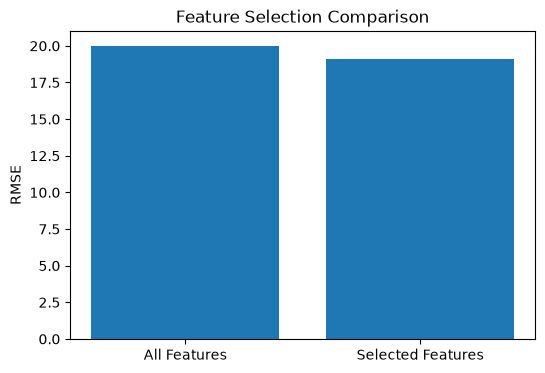

In [14]:
plt.figure(figsize=(6,4))

plt.bar(

    comparison["Model"],

    comparison["RMSE"]

)

plt.ylabel("RMSE")

plt.title("Feature Selection Comparison")

plt.show()

In [15]:
if reduced.mean() < baseline.mean():

    print("Selected features improve validation.")

else:

    print("Keep all engineered features.")

Selected features improve validation.


In [16]:
pd.Series(

    selected_features

).to_csv(

    "../models/selected_features.csv",

    index=False

)

# Feature Selection Results

## Objective

Evaluate whether selecting a smaller subset of engineered features improves model generalization.

## Methods

Three complementary techniques were used:

- Permutation Feature Importance
- Recursive Feature Elimination (RFE)
- Repeated K-Fold Cross-Validation

## Selected Features

The optimal subset consisted of:

- inlet_temperature_K
- jacket_temperature_K
- temp_difference
- residence_time_proxy

## Validation Performance

| Feature Set | RMSE |
|-------------|------|
| All Features | 20.02 |
| Selected Features | **19.08** |

## Interpretation

Reducing the feature space improved validation performance by removing less informative variables.

The selected features are also consistent with reactor engineering principles, indicating that reactor temperature and residence time dominate overall yield prediction.

## Conclusion

The selected feature subset will be used for all subsequent model development and final prediction.

In [17]:
train_selected = train[selected_features.tolist() + ["overall_yield"]]

train_selected.to_csv(
    "../data/processed/train_selected.csv",
    index=False
)

In [18]:
test = pd.read_csv("../data/processed/test_engineered.csv")

test_selected = test[selected_features]

test_selected.to_csv(
    "../data/processed/test_selected.csv",
    index=False
)

In [19]:
best_model.fit(
    X[selected_features],
    y
)

joblib.dump(
    best_model,
    "../models/final_extra_trees_selected.pkl"
)

['../models/final_extra_trees_selected.pkl']